<a href="https://colab.research.google.com/github/NguyenTien-beep/DAP391m/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Code sample:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

## Toy Example(MNIST digits)
#### Build  CNN model

In [ ]:
#Toy Example(MNIST digits):

from keras import layers
from keras import models

#define model
model = models.Sequential()
#define convolutional layer
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
#define convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
#define convolutional layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

#Add classfier at the top
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Train model

In [ ]:
#Training the convnet on MNIST images
from keras.datasets import mnist
from keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 55ms/step - accuracy: 0.9060 - loss: 0.3009
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.9736 - loss: 0.0878
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.9819 - loss: 0.0595
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9861 - loss: 0.0459
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.9884 - loss: 0.0377


#### Evaluate model

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9860 - loss: 0.0474
accuracy: 0.9860000014305115


# Visualization of covnets learning process


#### Load model

In [ ]:
from keras import models
from keras.models import load_model

#load model from file (we don't create model from scratch)
model = load_model('cats_and_dogs.h5')
model.summary()

#Save model diagram in file
from keras.utils import plot_model
plot_model(model, to_file='model.png')

#Show diagram
print("\nShow diagram:")
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img= mpimg.imread('model.png')
plt.imshow(img)

#### Load image

Tensor shape: (1, 150, 150, 3)


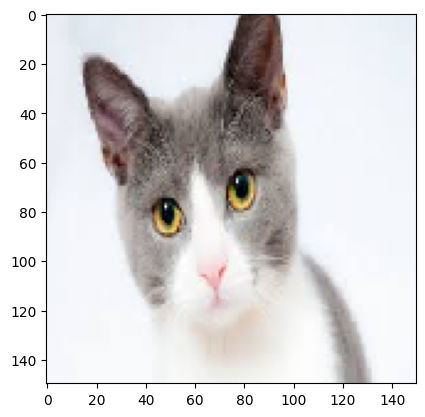

In [ ]:
#load image
img_path = 'cat2.png'
from keras.preprocessing import image
import numpy as np
img = image.load_img(img_path, target_size=(150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

print("Tensor shape:",img_tensor.shape)

#Show image
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0])
plt.show()

#### Visualize 4th and 7th channel

In [ ]:
from keras import models
from keras import layers

# Explanation of the issue and the workaround:
# The 'cats_and_dogs.h5' model failed to load in cell e4KFGifkSYAt due to version incompatibility.
# The 'model' variable currently holds the MNIST model, which expects (28, 28, 1) input.
# The 'img_tensor' (cat image) has shape (1, 150, 150, 3).
# To resolve the 'ValueError: Input incompatible with the layer' error and allow visualization code to run,
# we will temporarily define a new simple convolutional model that accepts the cat image's input shape.
# This model is NOT the original 'cats_and_dogs.h5' model and is for demonstration purposes only.
# It will be overwritten by the VGG16 model in a later cell.

# Define a temporary model compatible with img_tensor
temp_model = models.Sequential()
temp_model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Conv2D(128, (3, 3), activation='relu'))
temp_model.add(layers.MaxPooling2D((2, 2)))
temp_model.add(layers.Flatten())
temp_model.add(layers.Dense(512, activation='relu'))
# Assuming 2 classes (e.g., cat/dog) for a simple output layer for compatibility if needed later
temp_model.add(layers.Dense(2, activation='softmax'))

# Replace the existing 'model' with the temporary model for this section
model = temp_model

layer_outputs = [layer.output for layer in model.layers[:8]]
activation_model = models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

activations = activation_model.predict(img_tensor)
first_layer_activation = activations[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step



In my case the forth channel detects diagonal edges.
But your result can differ while specific filters learned by CNN are not deterministic.


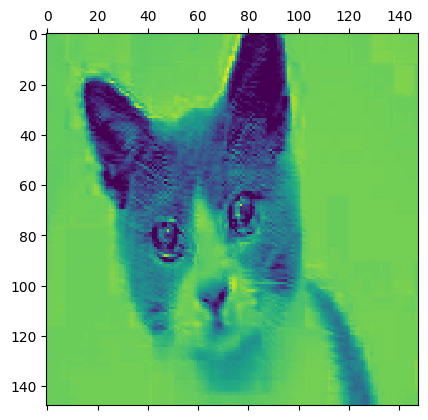

In [ ]:
#Visualizing the fourth channel
import matplotlib.pyplot as plt
plt.matshow(first_layer_activation[0, :, :, 4], cmap='viridis')
print("\nIn my case the forth channel detects diagonal edges.\nBut your result can differ while specific filters learned by CNN are not deterministic.")

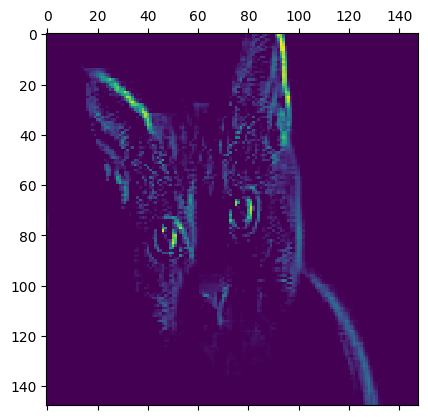

In [ ]:
# Seventh channel of the activation of the first layer on the test cat
plt.matshow(first_layer_activation[0, :, :, 7], cmap='viridis')

#### Visualize every channel

/tmp/ipykernel_150/3299126685.py:23: RuntimeWarning: invalid value encountered in divide
  channel_image /= channel_image.std()
/tmp/ipykernel_150/3299126685.py:26: RuntimeWarning: invalid value encountered in cast
  channel_image = np.clip(channel_image, 0, 255).astype('uint8')


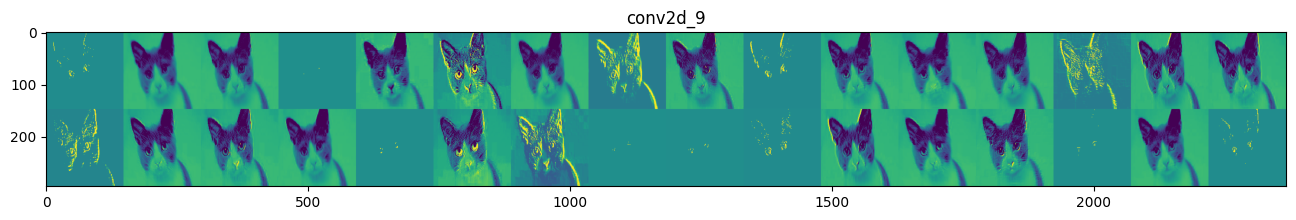

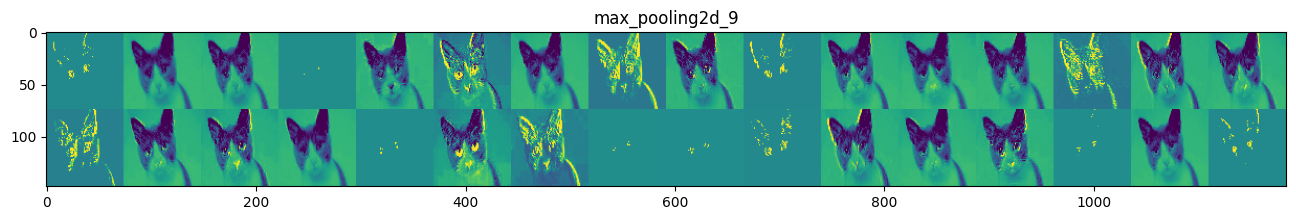

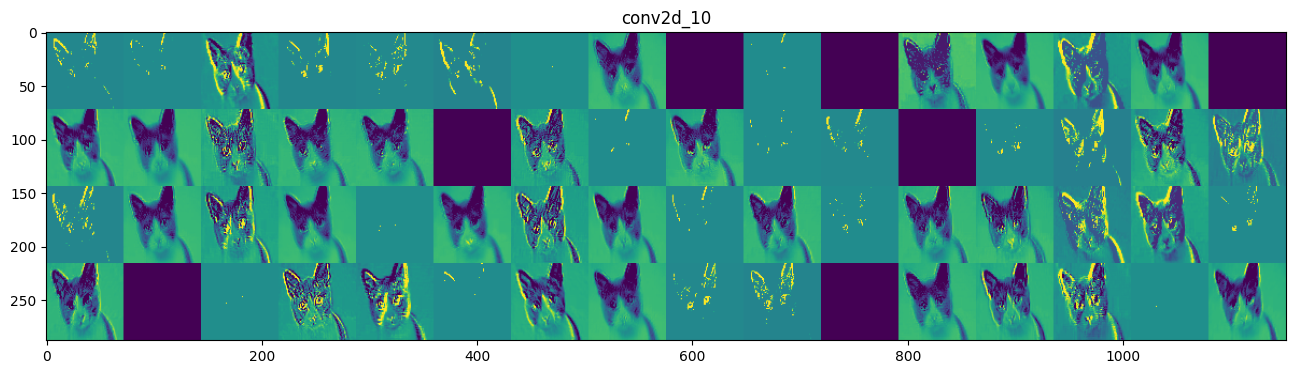

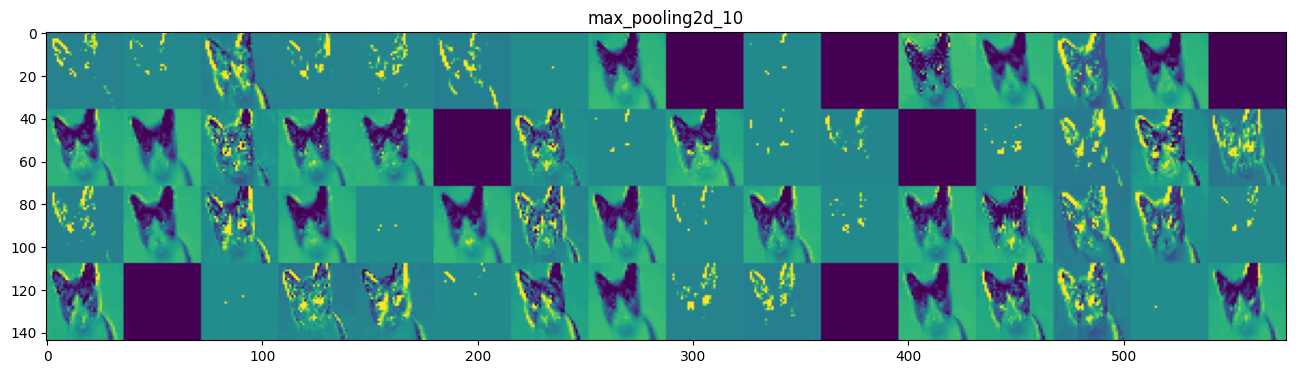

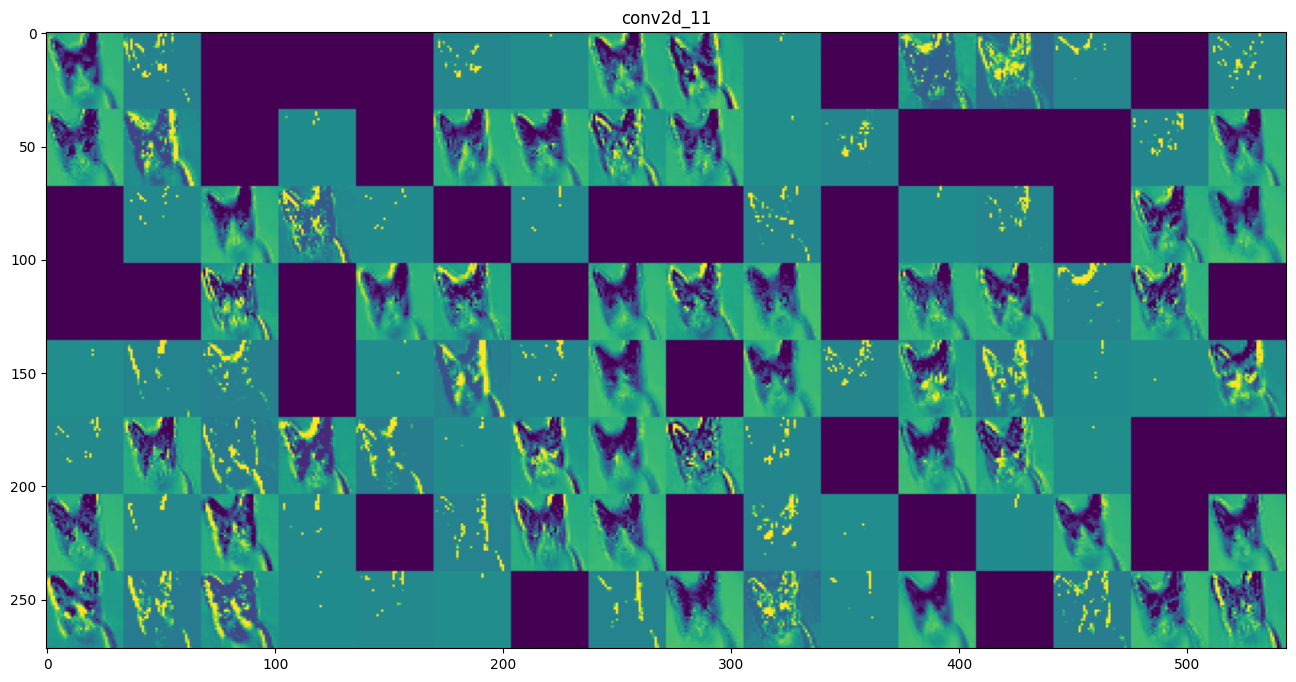

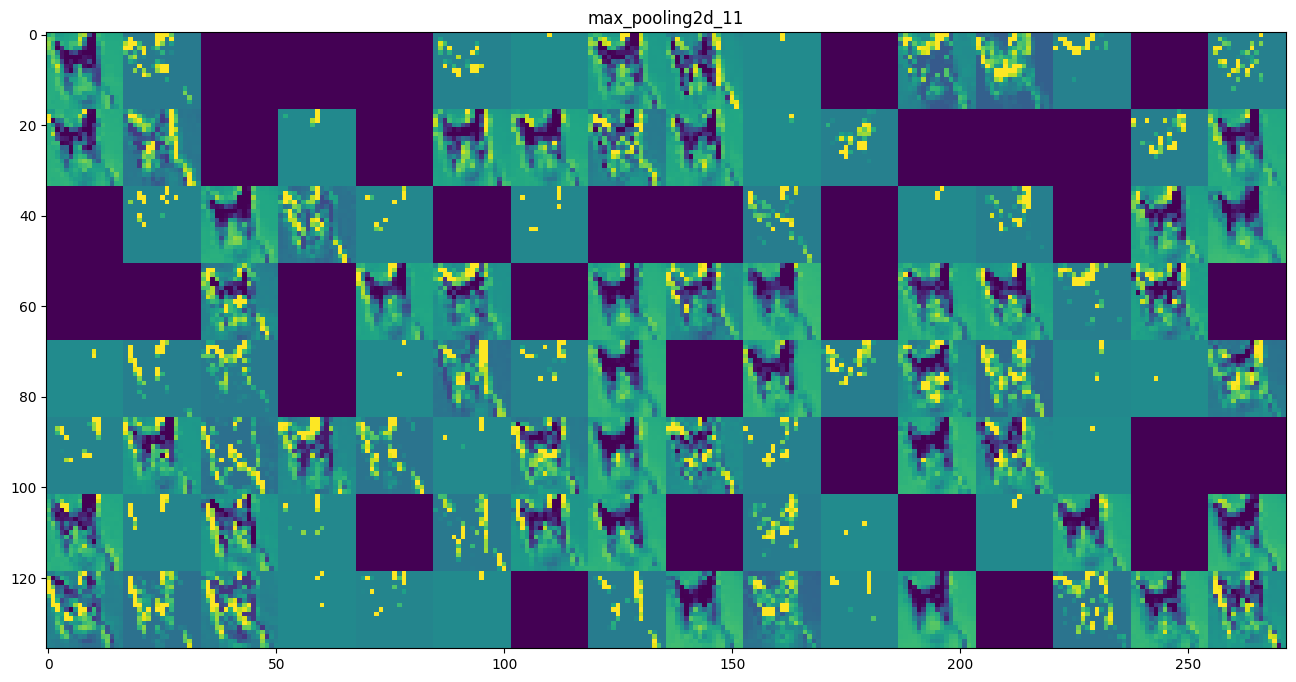

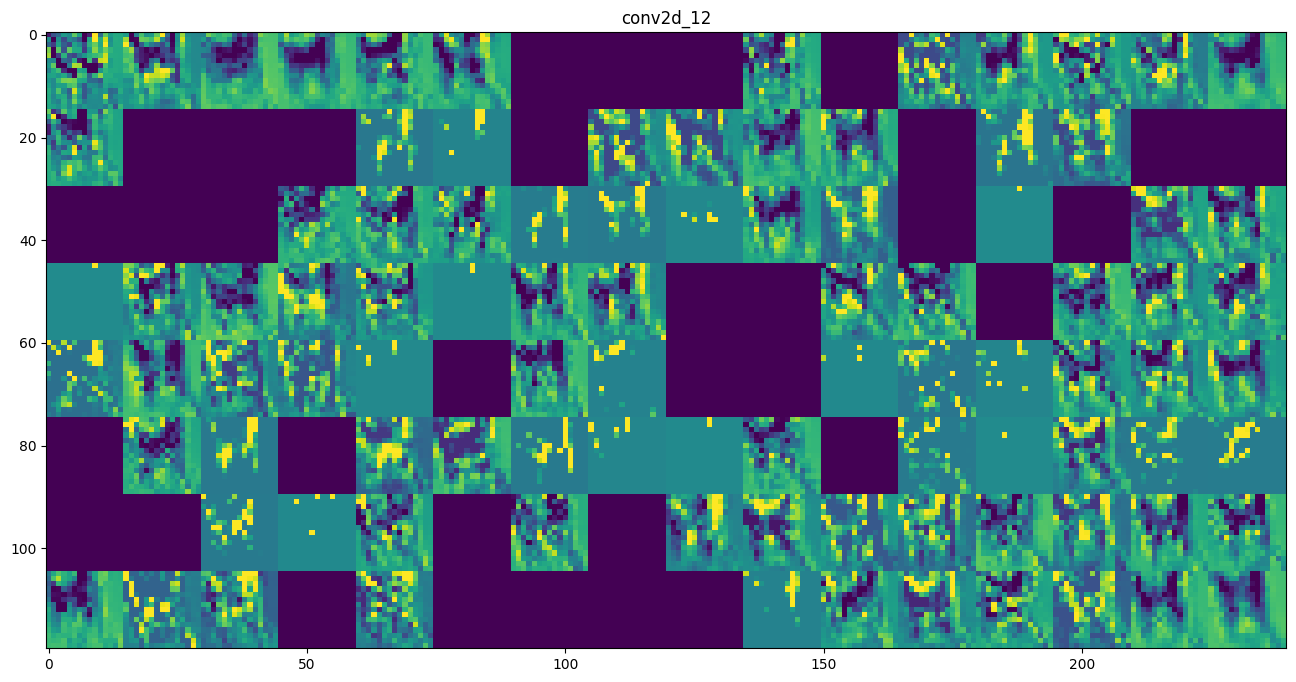

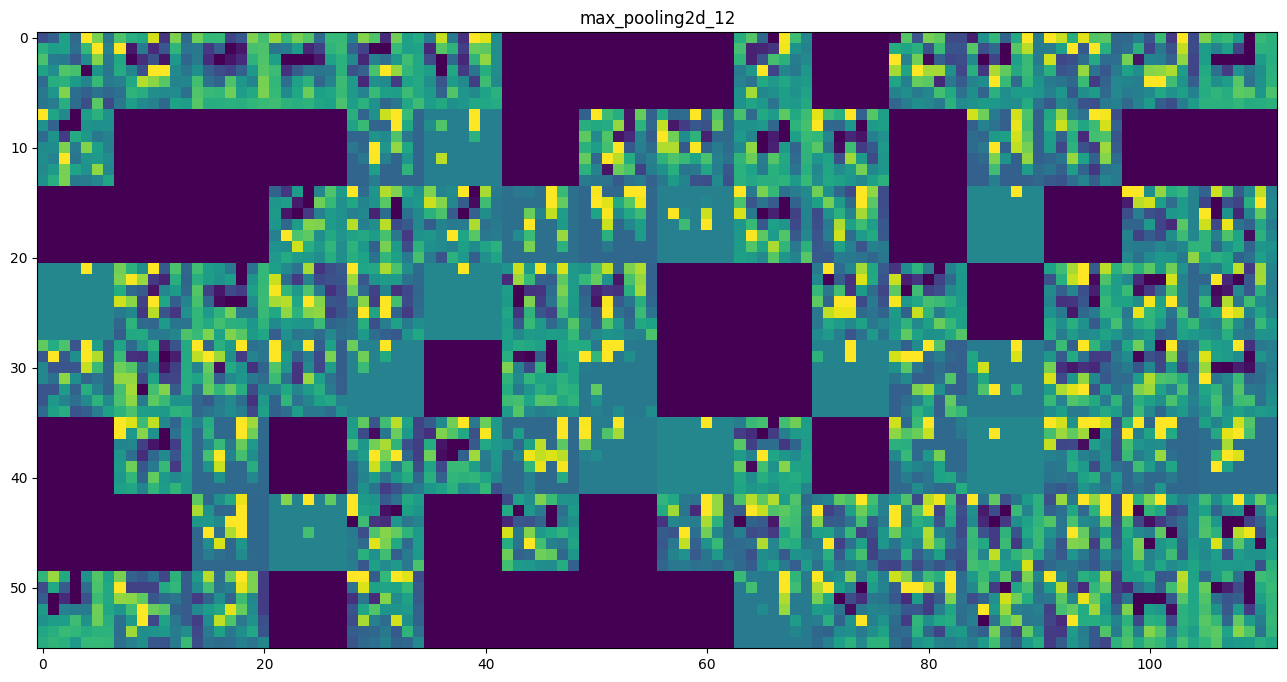

In [ ]:
#Visualizing every channel in every intermediate activation

layer_names = []
for layer in model.layers[:8]:
    layer_names.append(layer.name)

images_per_row = 16

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]

    size = layer_activation.shape[1]

    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,
                                             :, :,
                                             col * images_per_row + row]
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

# Visualizing covnet filters
#### Load VGG16 model

In [ ]:
#load VGG16 model
from keras.applications.vgg16 import VGG16
model = VGG16(weights='imagenet')

from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
import numpy as np

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


#### Load image and make prediction

In [ ]:
#load image
img_path = 'elephant1.png'
img = image.load_img(img_path, target_size=(224, 224))

#createfloat32 Numpy array of shape (224, 224, 3)
x = image.img_to_array(img)

#Adds a dimension to transform the array into a batch of size
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

#make prediction for selected image
preds = model.predict(x)
print('most probably 3 classes:\n', decode_predictions(preds, top=3)[0])
# 386 is the number of the african elephant class
print('predicted class number:\n',np.argmax(preds[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
most probably 3 classes:
 [('n02504458', 'African_elephant', np.float32(0.8887968)), ('n01871265', 'tusker', np.float32(0.102238)), ('n02504013', 'Indian_elephant', np.float32(0.008635464))]
predicted class number:
 386


#### Create heatmap

In [ ]:
import tensorflow as tf
from keras import backend as K

# Get "African elephant” entry from the prediction vector
african_elephant_class_idx = 386

# Output feature map of the block5_conv3 layer, the last convolutional layer in VGG16
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that returns the output of the last convolutional layer
# and the predictions for the input image.
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.output]
)

# Use tf.GradientTape to compute gradients
with tf.GradientTape() as tape:
    # Ensure the input tensor is watched by the tape
    # x is already preprocessed and a numpy array, convert to tf.Tensor
    x_tf = tf.cast(x, tf.float32)

    # Get the output of the last conv layer and the predictions
    last_conv_layer_output, preds = grad_model(x_tf)

    # Get the score for the African elephant class
    class_channel = preds[:, african_elephant_class_idx]

# Compute the gradient of the African elephant class score with respect to the output of the last conv layer
grads = tape.gradient(class_channel, last_conv_layer_output)

# Vector of shape (512,), where each entry is the mean intensity of the gradient over a specific feature-map
# This is Global Average Pooling of the gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Convert tensors to numpy for further processing
pooled_grads_value = pooled_grads.numpy()
conv_layer_output_value = last_conv_layer_output.numpy()[0] # Get the first (and only) image from batch

# Multiply each channel in the feature-map array by importance of the channel
for i in range(pooled_grads_value.shape[-1]): # Iterate through the channels
    conv_layer_output_value[:, :, i] *= pooled_grads_value[i]

# The channel-wise mean of the resulting feature map is the heatmap of the class activation.
heatmap = np.mean(conv_layer_output_value, axis=-1)

print("pooled_grads_value (first 5 values):\n", pooled_grads_value[:5])
print("heatmap shape:", heatmap.shape)

pooled_grads_value (first 5 values):
 [ 3.4950558e-06 -2.1809476e-06  6.3940956e-06  3.6473634e-07
 -5.5876112e-06]
heatmap shape: (14, 14)


#### Normalize heatmap

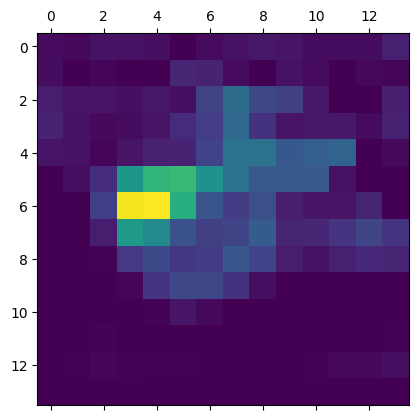

In [ ]:
#Normalize values between 0 and 1
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
#Show heatmap
plt.matshow(heatmap)

#### Join the heatmap and original  image


The most informative area of the image is the head of small elephant.


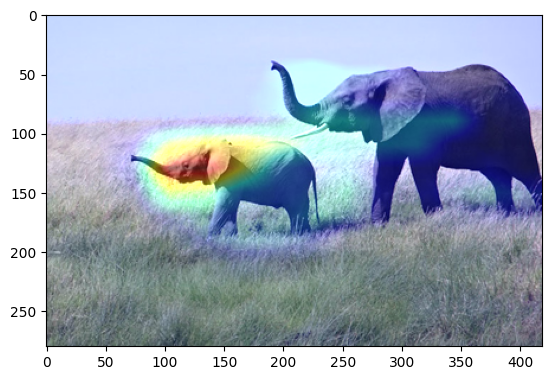

In [ ]:
#install cv2 (opencv) is neccessary
#!pip install opencv-python
import cv2
import matplotlib.image as mpimg
img_name='elephant_heatmap.png'

img = cv2.imread(img_path)
heatmap2 = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

#Converts the heatmap to RGB
heatmap2 = np.uint8(255 * heatmap2)
#Create colorMap using heatmap,higher value mean more reddishcolor
heatmap2 = cv2.applyColorMap(heatmap2, cv2.COLORMAP_JET)

#join heatmap and image
superimposed_img = heatmap2 * 0.4 + img
cv2.imwrite(img_name, superimposed_img)

#show image
img= mpimg.imread(img_name)
plt.imshow(img)
print("\nThe most informative area of the image is the head of small elephant.")

# Text vectorization


In [ ]:
#Embedding layer takes at least two arguments: the number of possible tokens
#(here, 1,000: 1 + maximum word index) and the dimensionality of the embeddings (here, 64).
from keras.layers import Embedding

embedding_layer = Embedding(1000, 64)